In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.optimize as spyo
import matplotlib.pyplot as plt

SP500_URL = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
sp500_table = pd.read_html(
    SP500_URL, storage_options={'User-Agent': 'Mozzilla/5.0'}
)[0]
companies = sp500_table['Symbol'].str.replace('.', '-').tolist()
realisation_matrix = yf.download(companies, period='5y')['Close']

[*********************100%***********************]  503 of 503 completed


In [2]:
realisation_matrix.head(5)

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-07-29,147.346542,141.962891,98.940292,143.470001,109.868866,36.609592,293.052826,621.700012,153.014969,51.764179,...,28.257837,96.501068,58.647690,49.033726,117.746101,255.279999,118.651756,151.307465,548.099976,192.966980
2021-07-30,147.887024,142.177277,96.801170,144.009995,109.769073,37.085041,292.436005,621.630005,153.823456,51.868404,...,27.365393,95.117767,58.187309,47.902107,118.489906,247.259995,119.635139,151.939667,552.479980,191.624573
2021-08-02,147.732590,141.845917,96.093674,145.490005,109.714600,37.284729,290.963257,618.750000,154.007278,51.555744,...,27.762936,95.156471,58.451595,47.910435,118.292183,272.380005,120.545677,151.558456,550.969971,191.066788
2021-08-03,148.495041,143.639496,96.759560,145.649994,110.803406,37.408348,293.209351,621.280029,154.981171,51.929203,...,28.022554,91.973953,58.570961,48.426315,120.448265,269.489990,121.483505,142.911819,546.739990,192.948029
2021-08-04,148.890762,143.239807,95.785713,147.399994,110.304375,37.484417,291.598419,625.679993,158.564453,51.025936,...,27.616905,88.114288,58.784103,47.294712,119.252548,266.420013,121.574585,137.816788,560.000000,193.600372


In [3]:
# Denoising Matrix

# Drop tickers missing more than 5% of trading days
threshold = len(realisation_matrix) * 0.95
clean_prices = realisation_matrix.dropna(thresh=threshold, axis=1)

# Forward-fill and backward-fill tiny remaining gaps
clean_prices = clean_prices.ffill().bfill()

# Log taken for time additivity and symmetry. Making returns behave more
# like the normal distribution.
returns = np.log(clean_prices / clean_prices.shift(1)).dropna()

# Splitting data in order to train and test model.
split = int(len(returns) * 0.8)
returns_train = returns.iloc[:split]
returns_test = returns.iloc[split:]

# Standardising data as required for RMT.
standardized_returns_train = (
    (returns_train - returns_train.mean()) / returns_train.std()
)
x = standardized_returns_train.to_numpy()
n_obs, n_assets = x.shape

# Empirical Correlation Matrix
corr_empirical = 1 / n_obs * np.dot(x.T, x)
eigenvalues, eigenvectors = np.linalg.eigh(corr_empirical)

# Marchenko-Pastur Bound (upper)
lambda_plus = (1 + np.sqrt(n_assets / n_obs)) ** 2

# Treating eigenvalues lying in MP bounds as noise, and replacing such
# values by their mean.
signal = eigenvalues > lambda_plus
mean_noise = np.mean(eigenvalues[~signal])
eigenvalues_clean = eigenvalues.copy()
eigenvalues_clean[~signal] = mean_noise

# Reconstructing denoised matrix using eigenvalue decompostion, and
# renormalising
corr_clean = eigenvectors @ np.diag(eigenvalues_clean) @ eigenvectors.T
variances = np.diag(corr_clean)
corr_clean = (
    np.outer(1 / np.sqrt(variances), 1 / np.sqrt(variances)) * corr_clean
)

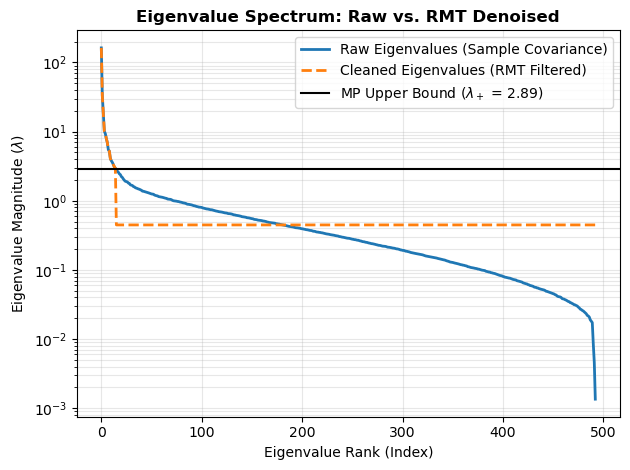

In [4]:
idx = np.argsort(eigenvalues)[::-1]
evals_raw_sorted = eigenvalues[idx]
evals_clean_sorted = eigenvalues_clean[idx]
plt.plot(
    evals_raw_sorted,
    label='Raw Eigenvalues (Sample Covariance)',
    linewidth=2,
)
plt.plot(
    evals_clean_sorted,
    label='Cleaned Eigenvalues (RMT Filtered)',
    linestyle='--',
    linewidth=2,
)
plt.axhline(
    y=lambda_plus,
    color='black',
    linewidth=1.5,
    label=rf'MP Upper Bound ($\lambda_+$ = {lambda_plus:.2f})',
)
plt.title(
    'Eigenvalue Spectrum: Raw vs. RMT Denoised',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Eigenvalue Rank (Index)', fontsize=10)
plt.ylabel(r'Eigenvalue Magnitude ($\lambda$)', fontsize=10)
plt.yscale('log')
plt.legend(loc='upper right')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Optimising portfolios (w) using the Sharpe Ratio for both Clean and
# Raw Covariance Matrices


# Sharpe Ratio as function of w
def sharpe_ratio(w, mu, sigma, rf=0.04):
    numerator = np.dot(w, mu) - rf  # Returns
    denominator = np.sqrt(np.dot(w, np.dot(sigma, w)))  # Risk
    sharpe = numerator / denominator
    # Negative to convert maximisation to minimisation for
    # scipy.optimize.minimize
    return -sharpe


# Annual daily asset standard deviation and annual mean returns, scaled
# accordingly with time
sd_yearly = returns_train.std().to_numpy() * np.sqrt(252)
mu_yearly = returns_train.mean().to_numpy() * 252

# Converting correlation matrices to covariance matrices
sigma_clean = np.diag(sd_yearly) @ corr_clean @ np.diag(sd_yearly)
sigma_raw = np.diag(sd_yearly) @ corr_empirical @ np.diag(sd_yearly)

# Initial guess (can be optimised)
initial = np.ones(n_assets) / n_assets

# Bounds and constraints placed upon portfolio (w)
bounds = [(0, 1) for _ in range(n_assets)]
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

# Minimising Sharpe Ratio with corresponding clean and raw data
optimise_clean = spyo.minimize(
    fun=sharpe_ratio,
    x0=initial,
    args=(mu_yearly, sigma_clean),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
)
optimise_raw = spyo.minimize(
    fun=sharpe_ratio,
    x0=initial,
    args=(mu_yearly, sigma_raw),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
)
w_clean = optimise_clean.x
w_raw = optimise_raw.x

# Computing Sharpe Ratio on out of sample data
test_returns_matrix = returns_test.to_numpy()
daily_ret_clean = test_returns_matrix @ w_clean
daily_ret_raw = test_returns_matrix @ w_raw
rf_daily = 0.04 / 252  # Annual risk free rate to daily
sharpe_out_clean = (
    (np.mean(daily_ret_clean) - rf_daily)
    / np.std(daily_ret_clean)
    * np.sqrt(252)
)
sharpe_out_raw = (
    (np.mean(daily_ret_raw) - rf_daily)
    / np.std(daily_ret_raw)
    * np.sqrt(252)
)

In [6]:
total_growth_clean = np.prod(1 + daily_ret_clean) - 1
total_growth_raw = np.prod(1 + daily_ret_raw) - 1
growth_improvement = (
    (total_growth_clean - total_growth_raw) / abs(total_growth_raw)
) * 100
print(f'Clean Portfolio Cumulative Return: {total_growth_clean * 100:.2f}%')
print(f'Raw Portfolio Cumulative Return: {total_growth_raw * 100:.2f}%')
print(f'Growth Improvement: {growth_improvement:.2f}%')

Clean Portfolio Cumulative Return: 23.13%
Raw Portfolio Cumulative Return: 21.54%
Growth Improvement: 7.38%


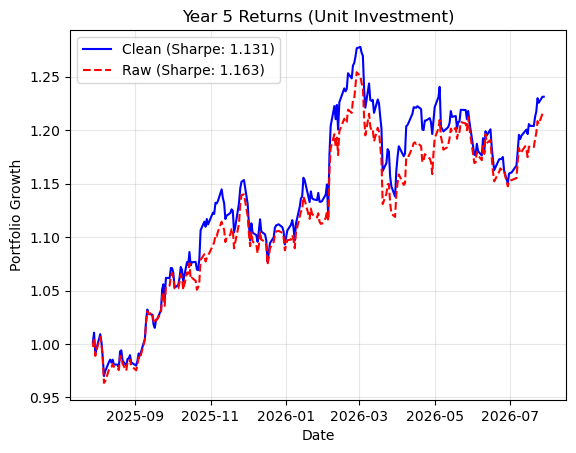

In [7]:
growth_clean = (1 + daily_ret_clean).cumprod()
growth_raw = (1 + daily_ret_raw).cumprod()
plt.plot(
    returns_test.index,
    growth_clean,
    label=f'Clean (Sharpe: {sharpe_out_clean:.3f})',
    color='blue',
)
plt.plot(
    returns_test.index,
    growth_raw,
    label=f'Raw (Sharpe: {sharpe_out_raw:.3f})',
    color='red',
    linestyle='--',
)
plt.title('Year 5 Returns (Unit Investment)')
plt.xlabel('Date')
plt.ylabel('Portfolio Growth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()